# Figure 6C — corrected AiED probability heatmap (aligned with Figure 6B / 6D)

**Run from top to bottom** on the lab machine where the original `.mat`, raw LFP and AiED model are accessible. This notebook keeps the original Figure6_C AiED spectrogram generation and ResNet-18 inference but corrects candidate ordering and geometry.

- Figure 6B is the **single source of truth** for the selected 30,162 global indices, the exact UMAP coordinates, and 20×20 x/y boundaries. First run the heatmap cell in `Figure6_B_corrected.ipynb` to generate `Figure6_B_grid.npz`.
- The original Figure 6C refit UMAP on **30,162** rows, while Figure 6B fit UMAP on **31,847** before selecting the retained 30,162. Even with the same random seed these are not the same coordinate system. Here we **load B's selected embedding**, rather than refitting UMAP.
- Record an explicit mapping from each generated AiED image's **local 0..30161 `global_count`** to the canonical **31,847-space global feature index**. Reorder model probabilities through this mapping before binning, rather than assuming MATLAB block iteration and sorted feature files have the same order.
- Preserve the original Figure 6C probability definition: `P_AiED = 1 - softmax_output[:, 1]` (the original code's `1 - mean(class-1 probability)`). Confirm that `ImageFolder` class 0 is `IEDS` and class 1 is `NON_IEDS`.
- Every selected candidate is assigned once (including bin extrema). For this min-5 display version, bins with fewer than 5 candidates are shown as white, while all candidate counts and raw bin means remain unchanged in the saved grid. Stop with a clear error instead of silently plotting if candidate alignment fails.

**Output:** `Figure6_C_corrected.png`, `.pdf`, `_grid.npz`, and `_candidate_alignment.npz`. Paths and model setup below match your original notebook where possible; adjust only if your working directory differs.

In [1]:
# libraries
from __future__ import print_function, division
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import os
import h5py
import re
import shutil
import copy
import time
import random
import warnings 
import operator
from datetime import datetime
from tqdm import tqdm, tqdm_notebook
from matplotlib.pyplot import specgram
import torch
import torchvision
from torchvision import datasets, models, transforms
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
# from torchtext import data
from sklearn.metrics import precision_score, f1_score, recall_score, accuracy_score, confusion_matrix
from sklearn.metrics.cluster import contingency_matrix
import joblib
import csv
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from scipy.io import loadmat

In [2]:
# Patient/channel configuration
pt_ch_mapping = {
    "EC130_200": [1, 13],
    "EC133_200": [282, 291, 292, 293],
    "EC135_200": [303],
    "EC137_200": [257, 258, 259, 269],
    "EC143_200": [339],
    "EC157_200": [321, 332, 333, 334],
    "EC162_200": [85, 86],
    "EC175_200": [301, 302],
    "EC183_200": [290],
    "EC186_200": [299, 300, 301],
    "EC187_200": [309, 310],
    "EC191_200": [2, 3, 4],
    "EC196_200": [300, 301, 303],
    "EC219_200": [399, 400, 402, 403],
    "EC220_200": [53, 54, 76, 77],
    "EC221_200": [376, 377],
    "EC222_200": [267, 268, 269, 270],
}

# Original expected counts
patient_num = {
    "EC130_200": 1465,
    "EC133_200": 1220,
    "EC135_200": 344,
    "EC137_200": 7222,
    "EC143_200": 881,
    "EC157_200": 4747,
    "EC162_200": 2398,
    "EC175_200": 518,
    "EC183_200": 220,
    "EC186_200": 1710,
    "EC187_200": 1315,
    "EC191_200": 642,
    "EC196_200": 594,
    "EC219_200": 2015,
    "EC220_200": 2572,
    "EC221_200": 859,
    "EC222_200": 3125,
}

EXCLUDED_PATIENTS = {"EC130_200", "EC183_200"}
EXPECTED_GLOBAL_N = 31847
EXPECTED_SELECTED_N = 30162

pathname = "/scratch/dazhang/MATLAB/"

print("Expected total:", sum(patient_num.values()))
print("Expected selected:", sum(
    n for patient, n in patient_num.items()
    if patient not in EXCLUDED_PATIENTS
))

Expected total: 31847
Expected selected: 30162


In [3]:
import h5py
import numpy as np
import os, glob
from scipy.io import savemat

def deref_matlab_string_or_ref(f, item):
    # Case 1: HDF5 object reference
    if isinstance(item, h5py.Reference):
        return f[item]

    # Case 2: Dataset containing ASCII codes for string
    if isinstance(item, h5py.Dataset):
        data = item[()]  # get numpy array
        if np.issubdtype(data.dtype, np.integer):  # likely ASCII codes
            return ''.join(chr(c) for c in data.flatten())
        else:
            return data

    # Case 3: Numpy scalar or array
    if isinstance(item, np.ndarray) or np.isscalar(item):
        data = np.array(item)
        # If it's object reference inside an array
        if data.dtype == object and len(data) > 0 and isinstance(data[0], h5py.Reference):
            return f[data[0]]
        # If it's ASCII code array
        if np.issubdtype(data.dtype, np.integer):
            return ''.join(chr(c) for c in data.flatten())

    # Case 4: Something else (like already a string)
    if isinstance(item, (str, bytes)):
        return item.decode() if isinstance(item, bytes) else item

    # If none of the above
    return item

In [4]:
def load_rdata_field(f, field):
    """Load a field like 'ripples' or 'Rspikes' from q/Rdata robustly."""
    path = f['q']['Rdata'][field]
    data = np.array(path)

    results = []
    if data.dtype == object:  # multiple blocks
        for ref in data.flatten():
            if isinstance(ref, h5py.Reference):
                results.append(np.array(f[ref]))
    else:  # single dataset
        results.append(data)

    return results

In [5]:
# Original Figure6_C block-map and empty-block configuration; patient/channel
# configuration is inherited above from Figure6_B_corrected verbatim.
import collections
pathname = '/scratch/dazhang/MATLAB/'
patient_block_map = collections.defaultdict(list)
for patient, channal_list in pt_ch_mapping.items():
    path = pathname + patient+'/'
    pt = patient[:-4]
    for cur_channel in channal_list:
        cur_channel = str(cur_channel)
        file_path = "/data/an/transformed/RR_h_referential_wSPKS/"+pt+"/AN/"+pt+"_AN_ch"+cur_channel+"_wSPKS.mat"
        block_names = []
        with h5py.File(file_path, "r") as f:
            blocks_refs = f['q']['blocks'][:]
            for i in range(blocks_refs.shape[1]):
                ref = blocks_refs[0,i]
                dataset = f[ref][:]          # dereference the object
                text = ''.join(chr(c) for c in dataset.flatten())  # convert char codes to string
                block_names.append(text)
            print("Raw data:", pt,  block_names)
            patient_block_map[pt] = block_names

        break
print("patient_block_map: ", patient_block_map)

all_res = []
start_end1 = []

empty_blocks = {"EC133_ch282":{'B67'},
 "EC137_ch259":{'B176'},
 "EC183_ch290":{'B132','B139','B142'},
# The followings are bad channels
 "EC220_ch55":{'B24','B27'},
 "EC220_ch75":{'B24','B27'},
 "EC221_ch375":{'B36','B47'},
 "EC221_ch374":{'B36','B47'},
 "EC196_ch302":{'B21'},
 "EC183_ch289":{'B132','B139','B142','B164'},
 "EC175_ch303":{'B11'},
 "EC157_ch322":{'B46'},
 "EC143_ch330":{'B35'},
 "EC137_ch260":{'B158','B185'},
 "EC137_ch259":{'B176'},
 "EC133_ch294":{'B60','B67'},
 "EC133_ch281":{'B60','B67'},
 "EC130_ch2":{'B8'},
 }

Raw data: EC130 ['B1', 'B6', 'B8']
Raw data: EC133 ['B60', 'B67']
Raw data: EC135 ['B5']
Raw data: EC137 ['B89', 'B99', 'B113', 'B124', 'B139', 'B158', 'B176', 'B185']
Raw data: EC143 ['B18', 'B34', 'B35']
Raw data: EC157 ['B12', 'B28', 'B31', 'B46']
Raw data: EC162 ['B1', 'B4', 'B13', 'B16']
Raw data: EC175 ['B11']
Raw data: EC183 ['B132', 'B139', 'B142', 'B164']
Raw data: EC186 ['B52', 'B56', 'B58']
Raw data: EC187 ['B27', 'B36', 'B39']
Raw data: EC191 ['B13']
Raw data: EC196 ['B21']
Raw data: EC219 ['B45', 'B48']
Raw data: EC220 ['B24', 'B27']
Raw data: EC221 ['B36', 'B47']
Raw data: EC222 ['B28', 'B31', 'B37', 'B40']
patient_block_map:  defaultdict(<class 'list'>, {'EC130': ['B1', 'B6', 'B8'], 'EC133': ['B60', 'B67'], 'EC135': ['B5'], 'EC137': ['B89', 'B99', 'B113', 'B124', 'B139', 'B158', 'B176', 'B185'], 'EC143': ['B18', 'B34', 'B35'], 'EC157': ['B12', 'B28', 'B31', 'B46'], 'EC162': ['B1', 'B4', 'B13', 'B16'], 'EC175': ['B11'], 'EC183': ['B132', 'B139', 'B142', 'B164'], 'EC186': 

## 1. Load Figure 6B's reference geometry before generating 30,162 AiED images

This reference records only the retained indices and coordinates; candidate-to-probability identity is established separately from the feature file+event row information below. `np.array_equal(embedding, reference)` alone would **not** verify that a CNN probability belongs to the same event.

In [6]:
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from scipy.spatial import cKDTree

B_GRID_PATH = "Figure6_B_grid.npz"  # Set absolute path if necessary.
OUTPUT_STEM = "Figure6_C_corrected"
RUN_IMAGE_GENERATION = True  # Set False ONLY if every expected image already exists and was made by this mapping.

if not os.path.isfile(B_GRID_PATH):
    raise FileNotFoundError(
        "Run Figure6_B_corrected.ipynb through its heatmap cell first. "
        f"Could not find: {os.path.abspath(B_GRID_PATH)}"
    )
with np.load(B_GRID_PATH, allow_pickle=False) as reference:
    b_selected_idx = reference["selected_global_idx"].copy()
    b_embedding = reference["each_pt_embedding"].copy()
    b_x_bins = reference["x_bins"].copy()
    b_y_bins = reference["y_bins"].copy()
    b_grid_count = reference["grid_count"].copy()

assert len(b_selected_idx) == EXPECTED_SELECTED_N
assert b_embedding.shape == (EXPECTED_SELECTED_N, 2)
assert b_x_bins.shape == (21,) and b_y_bins.shape == (21,)
assert b_grid_count.shape == (20, 20)
assert int(b_grid_count.sum()) == EXPECTED_SELECTED_N
assert np.array_equal(np.unique(b_selected_idx), b_selected_idx)
assert np.isfinite(b_embedding).all()
print("B reference:", os.path.abspath(B_GRID_PATH))
print("Selected rows:", len(b_selected_idx), "Occupied B bins:", np.count_nonzero(b_grid_count))

B reference: /home/dazhang/Documents/kleen_git/time-frequency-powerspectrum/llama2.c/clean_spike_ripple/Figure6_B_grid.npz
Selected rows: 30162 Occupied B bins: 245


## 2. Build B's canonical 31,847-space feature-file order

Each file is loaded **per patient, per channel, sorted by filename**, exactly as in `Figure6_B_corrected.ipynb`. Save the slice of global indices belonging to each file so that MATLAB/Rdata block order cannot silently permute the AiED probabilities.

In [7]:
file_list = []
file_slices = {}
file_patients = {}
all_specs_parts = []
all_specs_label_parts = []
row_offset = 0

for patient, channel_list in pt_ch_mapping.items():
    patient_n = 0
    patient_path = os.path.join(pathname, patient)
    for channel in channel_list:
        for file_path in sorted(glob.glob(os.path.join(patient_path, "*.mat"))):
            if "ls_ripple" not in file_path or "binsize_1_" in file_path:
                continue
            if f"Channel_{channel}_" not in file_path or "-empty" in file_path:
                continue
            file_path = os.path.abspath(file_path)
            if file_path in file_slices:
                raise AssertionError(f"Feature file repeated: {file_path}")
            specs = np.asarray(loadmat(file_path)["ls_ripple"])
            assert specs.ndim == 2 and specs.shape[1] == 60, (file_path, specs.shape)
            n = specs.shape[0]
            file_list.append(file_path)
            file_slices[file_path] = slice(row_offset, row_offset + n)
            file_patients[file_path] = patient
            row_offset += n
            patient_n += n
            all_specs_parts.append(specs)
            all_specs_label_parts.extend([patient] * n)
    print(f"{patient}: loaded={patient_n}, expected={patient_num[patient]}")
    assert patient_n == patient_num[patient], (
        f"Feature count mismatch for {patient}: {patient_n} vs {patient_num[patient]}"
    )

all_specs = np.concatenate(all_specs_parts, axis=0)
all_specs_label = np.asarray(all_specs_label_parts, dtype=object)
selected_global_idx = np.flatnonzero(
    ~np.isin(all_specs_label, list(EXCLUDED_PATIENTS))
)
assert all_specs.shape == (EXPECTED_GLOBAL_N, 60)
assert len(selected_global_idx) == EXPECTED_SELECTED_N
assert np.array_equal(selected_global_idx, b_selected_idx), (
    "C canonical feature ordering does not match B's selected global indices"
)

# The exact B coordinates, never a new UMAP fit on the selected subset.
embedding = b_embedding.copy()
each_pt_embedding = embedding
selected_patients = all_specs_label[b_selected_idx]
assert not np.isin(selected_patients, list(EXCLUDED_PATIENTS)).any()
print("Canonical feature files:", len(file_list))
print("Global / selected candidates:", len(all_specs), len(each_pt_embedding))

EC130_200: loaded=1465, expected=1465
EC133_200: loaded=1220, expected=1220
EC135_200: loaded=344, expected=344
EC137_200: loaded=7222, expected=7222
EC143_200: loaded=881, expected=881
EC157_200: loaded=4747, expected=4747
EC162_200: loaded=2398, expected=2398
EC175_200: loaded=518, expected=518
EC183_200: loaded=220, expected=220
EC186_200: loaded=1710, expected=1710
EC187_200: loaded=1315, expected=1315
EC191_200: loaded=642, expected=642
EC196_200: loaded=594, expected=594
EC219_200: loaded=2015, expected=2015
EC220_200: loaded=2572, expected=2572
EC221_200: loaded=859, expected=859
EC222_200: loaded=3125, expected=3125
Canonical feature files: 132
Global / selected candidates: 31847 30162


## 3. Generate AiED CNN input images (original Figure 6C)

Retain the original spectrogram and image preprocessing function. The source `subject` naming convention embeds a local `global_count` for the 30,162 retained events. The next cell additionally records the *canonical B global feature index* for each of those local IDs.

In [8]:
### 4. GENERATE INPUT IMAGES FOR CNN:
IEDdir = '/home/dazhang/Documents/kleen_git/time-frequency-powerspectrum/llama2.c/clean_spike_ripple/aied/notebooks/SPECTS_compare/IEDS/'
non_IEDdir = '/home/dazhang/Documents/kleen_git/time-frequency-powerspectrum/llama2.c/clean_spike_ripple/aied/notebooks/SPECTS_compare/NON_IEDS/'
def spectimgs(eegdata, spikedf):    
    """
    SPECTS: GENERATE SPECTS FOR CNN
        INPUT: 1) eegdata, 2) spikedf (df from automated template-matching spike detector)
        OUTPUT: spects within ./SPECTS/IEDS
    """
    for i in tqdm(range(0,len(spikedf))): 
        samp_freq = int(float(spikedf.fs.values[0]))
        #######################################
        pad = 1 # d:1 number of seconds for window 
        dpi_setting = 300 # d:300
        Nfft = 128*(samp_freq/500) # d: 128 
        h = 3
        w = 3
        #######################################
        # try:
        IS_ied = spikedf.ied_or_not.values[i]

        subject = spikedf.subject.values[0]
        chan_name = int(spikedf.channel.values[i]) # zero idxed -1
        spikestart = spikedf.spikeTime.values[i][0] # start spike
        ### select eeg data row 
        ecogclip = eegdata.iloc[chan_name]
        ### filter out line noise
        b_notch, a_notch = signal.iirnotch(60.0, 30.0, samp_freq)
        ecogclip = pd.Series(signal.filtfilt(b_notch, a_notch, ecogclip)) 

        ### trim eeg clip based on cushion            
        ### mean imputation if missing indices
        end = int(float((spikestart+int(float(pad*samp_freq)))))
        start = int(float((spikestart-int(float(pad*samp_freq)))))
        if end > max(ecogclip.index):
            temp = list(ecogclip[list(range(spikestart-int(float(pad*samp_freq)), max(ecogclip.index)))])
            cushend = [np.mean(ecogclip)]*(end - max(ecogclip.index))
            temp = np.array(temp + cushend)
        elif start < min(ecogclip.index):
            temp = list(ecogclip[list(range(min(ecogclip.index), spikestart+pad*samp_freq))])
            cushstart = [np.mean(ecogclip)]*(min(ecogclip.index)-start)
            temp = np.array(cushstart, temp)
        else:
            temp = np.array(ecogclip[list(range(spikestart-int(float(pad*samp_freq)), 
                                        spikestart+int(float(pad*samp_freq))))]) 

        ### PLOT AND EXPORT:
        plt.figure(figsize=(h,w))
        specgram(temp, NFFT = int(Nfft), Fs = samp_freq, noverlap=int(Nfft/2), detrend = "linear", cmap = "YlOrRd") 
        plt.axis("off")
        plt.xlim(0, pad*2)
        plt.ylim(0,100)
        # plt.savefig(IEDdir+subject+"_"+str(spikestart)+"_"+str(chan_name)+".png", dpi = dpi_setting)
        # plt.savefig(IEDdir+subject+"_"+str(spikestart)+"_"+str(chan_name)+"_"+str(i) + ".png",dpi=dpi_setting)
        cur_count = int(subject.rsplit("_count", 1)[-1])
        global_count = cur_count + i
        if IS_ied==1:
            plt.savefig(IEDdir+subject+"_"+str(spikestart)+"_"+str(chan_name)+"_"+str(global_count) + ".png",dpi=dpi_setting)
        else:
            plt.savefig(non_IEDdir+subject+"_"+str(spikestart)+"_"+str(chan_name)+"_"+str(global_count) + ".png",dpi=dpi_setting)
        plt.close()


# spectimgs(data, spikes)

In [9]:
# Run this BEFORE CNN inference. Original C used MATLAB block order for image
# IDs and sorted filenames for features; now explicitly bridge those orders.
local_id_to_b_global_idx = []
all_counted_feature_files = set()
total_count = 0

# The original spectimgs() paths are absolute; inference below uses the same root.
for image_folder in (IEDdir, non_IEDdir):
    if RUN_IMAGE_GENERATION:
        os.makedirs(image_folder, exist_ok=True)

for pt, blocks in patient_block_map.items():
    if pt + "_200" in EXCLUDED_PATIENTS:
        continue
    channel_list = pt_ch_mapping[pt + "_200"]
    patient_path = os.path.join(pathname, pt + "_200")

    for each_channel in channel_list:
        raw_mat_path = (
            f"/data/an/transformed/RR_h_referential_wSPKS/{pt}/AN/"
            f"{pt}_AN_ch{each_channel}_wSPKS.mat"
        )
        with h5py.File(raw_mat_path, "r") as f:
            ripple_blocks = load_rdata_field(f, "ripples")
            spike_blocks = load_rdata_field(f, "Rspikes_THISchannel")
            assert len(ripple_blocks) == len(spike_blocks) == len(blocks), (
                pt, each_channel, len(ripple_blocks), len(spike_blocks), len(blocks)
            )
            for block_number, (ripples, spikes, block_name) in enumerate(
                zip(ripple_blocks, spike_blocks, blocks), start=1
            ):
                if (pt + "_ch" + str(each_channel) in empty_blocks and
                    block_name in empty_blocks[pt + "_ch" + str(each_channel)]):
                    continue

                feature_path = os.path.abspath(os.path.join(
                    patient_path,
                    f"ls_ripple_{pt}_Channel_{each_channel}_binsize_10_Block_{block_number}.mat"
                ))
                if feature_path not in file_slices:
                    # An empty/omitted block may have no retained feature file.
                    # Never assign its probabilities to another file by position.
                    ripples_check = np.atleast_2d(ripples)
                    if ripples_check.shape == (1, 2) and np.size(spikes) == 2:
                        continue
                    raise AssertionError(f"AiED events have no B feature file: {feature_path}")
                if feature_path in all_counted_feature_files:
                    raise AssertionError(f"Feature file used more than once: {feature_path}")
                all_counted_feature_files.add(feature_path)
                feature_slice = file_slices[feature_path]
                n_features = feature_slice.stop - feature_slice.start

                ripples = np.atleast_2d(ripples)
                spikes = np.atleast_1d(spikes)
                if ripples.shape == (1, 2) and spikes.shape == (2,):
                    if n_features != 0:
                        raise AssertionError(
                            f"Skipped nonempty canonical feature file: {feature_path}; n={n_features}"
                        )
                    continue

                spike_times_list = np.asarray(ripples.T).astype(int).tolist()
                spikes_or_not = [v[0] for v in spikes.T.tolist()]
                if len(spike_times_list) != n_features or len(spikes_or_not) != n_features:
                    raise AssertionError(
                        f"AiED event-to-B-feature row mismatch in {feature_path}: "
                        f"times={len(spike_times_list)}, spikes={len(spikes_or_not)}, "
                        f"features={n_features}"
                    )
                # Same original ImageFolder ID sequence, with an extra key into B.
                local_id_to_b_global_idx.extend(range(feature_slice.start, feature_slice.stop))
                if n_features == 0:
                    continue

                if RUN_IMAGE_GENERATION:
                    raw_file = (
                        f"/data/an/preprocessed/{pt}/{pt}_{block_name}/MAT files/"
                        f"{pt}_{block_name}_notched.mat"
                    )
                    a = loadmat(raw_file)
                    raw_lfp = np.hstack([a["d"][:, each_channel]])
                    train_lfp = raw_lfp[:, np.newaxis]
                    clean_lfp = np.nan_to_num(
                        train_lfp, nan=0.0, posinf=1e5, neginf=-1e5
                    )
                    clean_lfp = np.clip(clean_lfp, -65000, 65000)
                    LFP_df = pd.DataFrame([clean_lfp.reshape(-1)])
                    SPIKES = pd.DataFrame({
                        "channel": [0] * n_features,
                        "spikeTime": spike_times_list,
                        "ied_or_not": spikes_or_not,
                        "fs": [512] * n_features,
                        "subject": [f"{pt}_{block_name}_ch{each_channel}_count{total_count}"] * n_features,
                    })
                    spectimgs(LFP_df, SPIKES)

                total_count += n_features

local_id_to_b_global_idx = np.asarray(local_id_to_b_global_idx, dtype=np.int64)
expected_selected_files = {
    path for path in file_list if file_patients[path] not in EXCLUDED_PATIENTS
}
missing_files = expected_selected_files - all_counted_feature_files
extra_files = all_counted_feature_files - expected_selected_files
if missing_files or extra_files:
    raise AssertionError(
        f"Feature files not aligned: {len(missing_files)} missing, "
        f"{len(extra_files)} extra; missing examples: {sorted(missing_files)[:5]}"
    )
assert total_count == EXPECTED_SELECTED_N
assert len(local_id_to_b_global_idx) == EXPECTED_SELECTED_N
assert len(np.unique(local_id_to_b_global_idx)) == EXPECTED_SELECTED_N
assert np.array_equal(np.sort(local_id_to_b_global_idx), b_selected_idx), (
    "CNN-image IDs do not cover exactly the same 30,162 global candidates as B"
)
np.savez_compressed(
    OUTPUT_STEM + "_candidate_alignment.npz",
    image_global_count=np.arange(EXPECTED_SELECTED_N, dtype=np.int64),
    b_global_idx=local_id_to_b_global_idx,
    selected_global_idx=b_selected_idx,
)
print("AiED images/candidate mapping:", total_count)
print("All 30,162 images map 1:1 onto Figure6_B selected global indices.")

100%|██████████| 209/209 [00:17<00:00, 12.01it/s]

AiED images/candidate mapping: 30162
All 30,162 images map 1:1 onto Figure6_B selected global indices.


## 4. Original AiED image transform, class order, and ResNet-18 inference

A folder may contain images from earlier runs; the code checks that *every* local ID from 0 through 30161 appears exactly once. Keep only the intended `SPECTS_compare/IEDS` and `NON_IEDS` PNG files for this run (avoid stale duplicates); do not silently ignore mismatches.

In [10]:
# Original Figure6_C ResNet18 image preprocessing and ImageFolder convention.
eegdir = os.getcwd()
model_dir = eegdir + "/"
image_root = os.path.dirname(os.path.normpath(IEDdir))
imgs = os.path.basename(image_root)  # SPECTS_compare
proj_dir = os.path.dirname(image_root)

data_transforms = {
    imgs: transforms.Compose([
        transforms.Resize(224),
        transforms.Pad(1, fill=0, padding_mode="constant"),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}
class ImageFolderWithPaths(datasets.ImageFolder):
    def __getitem__(self, index):
        original_tuple = super().__getitem__(index)
        path = self.imgs[index][0]
        filename = os.path.splitext(os.path.basename(path))[0]
        local_global_count = int(filename.rsplit("_", 1)[-1])
        return original_tuple + (path, local_global_count)

image_dataset = ImageFolderWithPaths(
    os.path.join(proj_dir, imgs), data_transforms[imgs]
)
class_names = image_dataset.classes
print("Class order:", class_names)
assert class_names == ["IEDS", "NON_IEDS"], (
    "Original C used 1 - softmax[:,1] as P_AiED; expected [IEDS, NON_IEDS]. "
    f"Got {class_names!r}"
)
image_local_ids = np.asarray([
    int(os.path.splitext(os.path.basename(path))[0].rsplit("_", 1)[-1])
    for path, _ in image_dataset.samples
], dtype=np.int64)
assert len(image_local_ids) == EXPECTED_SELECTED_N, (
    f"Found {len(image_local_ids)} images, expected {EXPECTED_SELECTED_N}. "
    "Check stale images and failed image generation."
)
assert np.array_equal(np.sort(image_local_ids), np.arange(EXPECTED_SELECTED_N)), (
    "AiED image global_count IDs are missing, duplicated, or outside 0..30161"
)
dataloader = torch.utils.data.DataLoader(
    image_dataset, batch_size=1, shuffle=False, num_workers=0
)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Validated image count:", len(image_local_ids), "; device:", device)

Class order: ['IEDS', 'NON_IEDS']
Validated image count: 30162 ; device: cuda:0


In [11]:
# Original AiED model; preserve softmax output column 1 (NON_IEDS),
# then convert to P_AiED = 1 - that probability as in original C.
model = torch.load("aied/model_aied.pt", map_location=device)
model = model.to(device)
model.eval()
prob_by_global_count = np.full(EXPECTED_SELECTED_N, np.nan, dtype=float)
pred_by_global_count = np.full(EXPECTED_SELECTED_N, -1, dtype=int)
true_by_global_count = np.full(EXPECTED_SELECTED_N, -1, dtype=int)

with torch.no_grad():
    for iteration, (inputs, labels, paths, local_ids) in enumerate(dataloader, 1):
        inputs = inputs.to(device)
        probs = F.softmax(model(inputs), dim=1)
        local_id = int(local_ids.item())
        prob_by_global_count[local_id] = float(probs[0, 1].item())
        pred_by_global_count[local_id] = int(probs.argmax(dim=1).item())
        true_by_global_count[local_id] = int(labels.item())
        if iteration % 1000 == 0 or iteration == EXPECTED_SELECTED_N:
            print(f"AiED inferred {iteration}/{EXPECTED_SELECTED_N}")

assert np.isfinite(prob_by_global_count).all(), "Some AiED images were not inferred"
assert np.all((prob_by_global_count >= 0) & (prob_by_global_count <= 1))
print("All AiED probabilities ready:", len(prob_by_global_count))

AiED inferred 1000/30162
AiED inferred 2000/30162
AiED inferred 3000/30162
AiED inferred 4000/30162
AiED inferred 5000/30162
AiED inferred 6000/30162
AiED inferred 7000/30162
AiED inferred 8000/30162
AiED inferred 9000/30162
AiED inferred 10000/30162
AiED inferred 11000/30162
AiED inferred 12000/30162
AiED inferred 13000/30162
AiED inferred 14000/30162
AiED inferred 15000/30162
AiED inferred 16000/30162
AiED inferred 17000/30162
AiED inferred 18000/30162
AiED inferred 19000/30162
AiED inferred 20000/30162
AiED inferred 21000/30162
AiED inferred 22000/30162
AiED inferred 23000/30162
AiED inferred 24000/30162
AiED inferred 25000/30162
AiED inferred 26000/30162
AiED inferred 27000/30162
AiED inferred 28000/30162
AiED inferred 29000/30162
AiED inferred 30000/30162
AiED inferred 30162/30162
All AiED probabilities ready: 30162


## 5. Reindex local AiED probabilities into B's **global candidate** order

Do not use `prob_by_global_count[i]` together with `b_embedding[i]`: the former is keyed by original image generation order, while the latter is keyed by sorted feature-file order. The explicit `local_id_to_b_global_idx` mapping makes the lookup correct even if MATLAB block order differs.

In [12]:
assert np.array_equal(np.sort(local_id_to_b_global_idx), b_selected_idx)
prob_class1_by_B_global = np.full(EXPECTED_GLOBAL_N, np.nan, dtype=float)
prob_class1_by_B_global[local_id_to_b_global_idx] = prob_by_global_count

# Figure6_C original: 1 - mean(probability of class 1 / NON_IEDS).
# Mean(1 - p) = 1 - mean(p): same scientific quantity and direction.
selected_probs = 1.0 - prob_class1_by_B_global[b_selected_idx]
assert selected_probs.shape == (EXPECTED_SELECTED_N,)
assert np.isfinite(selected_probs).all()
assert np.all((selected_probs >= 0) & (selected_probs <= 1))
assert each_pt_embedding.shape == (EXPECTED_SELECTED_N, 2)

kmeans_label = KMeans(n_clusters=5, random_state=920, n_init=10).fit(
    each_pt_embedding
)
print("B-aligned AiED probability range:", selected_probs.min(), selected_probs.max())
print("Same candidate indices:", np.array_equal(selected_global_idx, b_selected_idx))
print("Same 30,162 UMAP positions:", np.array_equal(each_pt_embedding, b_embedding))

B-aligned AiED probability range: 4.76837158203125e-07 0.9985820283181965
Same candidate indices: True
Same 30,162 UMAP positions: True


## Optional: original Figure 6C cluster-level P_AiED summary

The original notebook also shows the 5-cluster means and SEM. Use the **B-aligned** AiED probabilities and B-aligned KMeans labels; do *not* subtract from 1 a second time. Original bar display order: KMeans clusters 2, 3, 0, 1, 4.

Displayed cluster 1 (KMeans 2): P_AiED=0.0436, SEM=0.0018
Displayed cluster 2 (KMeans 3): P_AiED=0.0355, SEM=0.0014
Displayed cluster 3 (KMeans 0): P_AiED=0.0737, SEM=0.0024
Displayed cluster 4 (KMeans 1): P_AiED=0.1234, SEM=0.0033
Displayed cluster 5 (KMeans 4): P_AiED=0.6542, SEM=0.0060


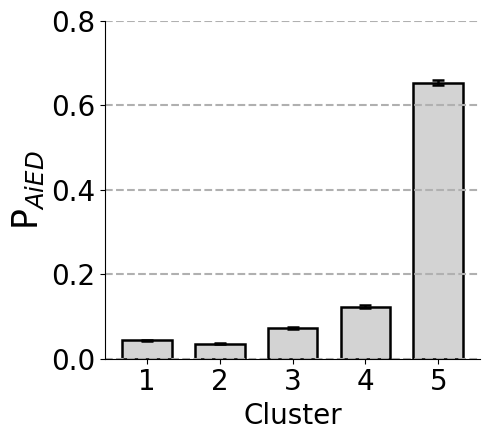

In [13]:
cluster_display_order = [2, 3, 0, 1, 4]
cluster_data = [
    selected_probs[np.asarray(kmeans_label.labels_) == cluster_id]
    for cluster_id in cluster_display_order
]
cluster_means = [float(np.mean(data)) for data in cluster_data]
cluster_sems = [
    float(np.std(data, ddof=1) / np.sqrt(len(data))) if len(data) > 1 else np.nan
    for data in cluster_data
]
for bar_index, (cluster_id, mean, sem) in enumerate(
    zip(cluster_display_order, cluster_means, cluster_sems), 1
):
    print(f"Displayed cluster {bar_index} (KMeans {cluster_id}): "
          f"P_AiED={mean:.4f}, SEM={sem:.4f}")

fig_bar, ax_bar = plt.subplots(figsize=(5, 4.5))
xpos = np.arange(5)
ax_bar.bar(
    xpos, cluster_means, width=0.68, color="lightgray",
    edgecolor="black", linewidth=1.8,
    yerr=cluster_sems, capsize=4,
    error_kw={"ecolor": "black", "elinewidth": 1.8, "capthick": 1.8},
)
ax_bar.set_xlabel("Cluster", fontsize=20)
ax_bar.set_ylabel("P$_{AiED}$", fontsize=25)
ax_bar.set_xticks(xpos)
ax_bar.set_xticklabels(["1", "2", "3", "4", "5"], fontsize=20)
ax_bar.tick_params(axis="y", labelsize=20)
ax_bar.set_ylim(0, max(0.8, max(cluster_means) + 0.08))
ax_bar.grid(True, axis="y", linestyle="--", linewidth=1.5)
ax_bar.spines["top"].set_visible(False)
ax_bar.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Bin using the exact Figure 6B 20×20 x/y edges and B's inclusion rule

Use `searchsorted(..., side="left") - 1` **with clipping**, just as in `Figure6_B_corrected`. Retain all candidates in the calculated and exported grid, but mask bins with fewer than 5 candidates for display only (as in Figure 6B min-5). Reject a grid-count mismatch before plotting.

In [14]:
grid_size = (20, 20)
x_bins = b_x_bins.copy()
y_bins = b_y_bins.copy()
min_vals = np.array([x_bins[0], y_bins[0]])
max_vals = np.array([x_bins[-1], y_bins[-1]])

x_idx = np.clip(
    np.searchsorted(x_bins, each_pt_embedding[:, 0], side="left") - 1,
    0, grid_size[0] - 1,
)
y_idx = np.clip(
    np.searchsorted(y_bins, each_pt_embedding[:, 1], side="left") - 1,
    0, grid_size[1] - 1,
)
grid_count = np.zeros(grid_size, dtype=np.int64)
grid_prob_sum = np.zeros(grid_size, dtype=float)
np.add.at(grid_count, (x_idx, y_idx), 1)
np.add.at(grid_prob_sum, (x_idx, y_idx), selected_probs)
assert int(grid_count.sum()) == EXPECTED_SELECTED_N

if not np.array_equal(grid_count, b_grid_count):
    changed = np.argwhere(grid_count != b_grid_count)
    for i, j in changed[:10]:
        print(f"bin ({i}, {j}): B={b_grid_count[i, j]}, C={grid_count[i, j]}")
    raise AssertionError(f"B/C candidate counts differ in {len(changed)} of 400 bins")

grid_probability_value = np.full(grid_size, np.nan, dtype=float)
occupied = grid_count > 0
grid_probability_value[occupied] = grid_prob_sum[occupied] / grid_count[occupied]
# Display-only filter, identical to Figure6_B_corrected_min5:
# bins with 0-4 candidates appear white; bins with >=5 retain their true means.
# The unfiltered grid_probability_value and grid_count are saved to _grid.npz
# so the exact 30,162-candidate B/C/D alignment is preserved.
MIN_CANDIDATES_PER_BIN = 5
low_count_bins = (grid_count > 0) & (grid_count <= MIN_CANDIDATES_PER_BIN)
masked_data = np.ma.masked_where(
    grid_count.T < MIN_CANDIDATES_PER_BIN,
    np.ma.masked_invalid(grid_probability_value.T)
)
assert np.array_equal(np.isnan(grid_probability_value), ~occupied)
assert int(np.ma.count(masked_data)) == int((grid_count >= MIN_CANDIDATES_PER_BIN).sum())
print(f"Minimum candidates per displayed bin: {MIN_CANDIDATES_PER_BIN}")
print("Occupied bins hidden:", int(low_count_bins.sum()))
print("Candidates in hidden bins:", int(grid_count[low_count_bins].sum()))
print("Occupied bins displayed:", int((grid_count >= MIN_CANDIDATES_PER_BIN).sum()))
print("Selected candidates:", len(each_pt_embedding))
print("Assigned candidates:", int(grid_count.sum()))
print("Occupied bins:", int(occupied.sum()))
print("B/C counts in every one of 400 bins: IDENTICAL")
print("Mean P_AiED range:", np.nanmin(grid_probability_value), np.nanmax(grid_probability_value))

Minimum candidates per displayed bin: 5
Occupied bins hidden: 13
Candidates in hidden bins: 38
Occupied bins displayed: 236
Selected candidates: 30162
Assigned candidates: 30162
Occupied bins: 245
B/C counts in every one of 400 bins: IDENTICAL
Mean P_AiED range: 0.006865024566650391 0.9685622714459896


## 7. Plot the corrected Figure 6C — B/D-matching KMeans boundaries

The plotted values are bin means of `P_AiED`. Only bins with at least 5 candidates are displayed; bins with 0–4 candidates are white, but remain in the unfiltered saved grid. This plot uses the same KNN-boundary procedure and style as the corrected Figure 6B / 6D, and the real mean-probability range on the colorbar.

Saved: Figure6_C_corrected.png / .pdf / _grid.npz


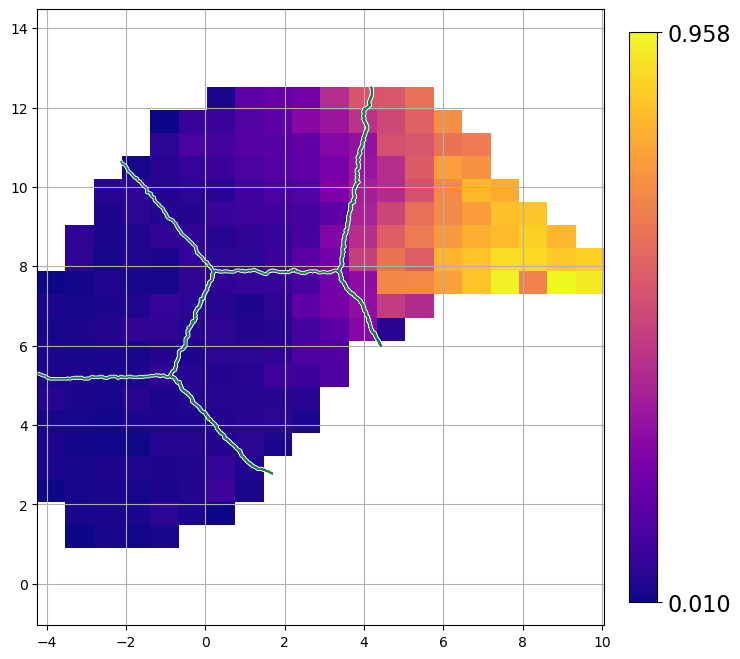

In [15]:
cmap = plt.colormaps["plasma"].copy()
cmap.set_bad(color="white")
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_facecolor("white")
ax.grid(True)
ax.axis("equal")
# Color limits must reflect VISIBLE bins after the minimum-count filter.
vmin = float(masked_data.min())
vmax = float(masked_data.max())
c2 = ax.imshow(
    masked_data, origin="lower", cmap=cmap,
    vmin=vmin, vmax=vmax,
    extent=[min_vals[0], max_vals[0], min_vals[1], max_vals[1]],
)

cluster_labels = np.asarray(kmeans_label.labels_)
xx, yy = np.meshgrid(
    np.linspace(min_vals[0], max_vals[0], 600),
    np.linspace(min_vals[1], max_vals[1], 600),
)
grid_points = np.c_[xx.ravel(), yy.ravel()]
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(each_pt_embedding, cluster_labels)
Z = knn.predict(grid_points).reshape(xx.shape)
tree = cKDTree(each_pt_embedding)
dist, _ = tree.query(grid_points, k=1)
Z_masked = np.ma.masked_where(dist.reshape(xx.shape) > 0.4, Z)

ax.contour(xx, yy, Z_masked, levels=[0.5, 1.5, 2.5, 3.5],
           colors="white", linewidths=2.6, alpha=0.95, zorder=10)
ax.contour(xx, yy, Z_masked, levels=[0.5, 1.5, 2.5, 3.5],
           colors="#1f7952", linewidths=1.2, alpha=1.0, zorder=11)

cbar = fig.colorbar(c2, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
cbar.set_ticks([vmin, vmax])
cbar.set_ticklabels([f"{vmin:.3f}", f"{vmax:.3f}"])
cbar.ax.tick_params(labelsize=16)
fig.savefig(OUTPUT_STEM + ".png", dpi=300, bbox_inches="tight")
fig.savefig(OUTPUT_STEM + ".pdf", bbox_inches="tight")
np.savez_compressed(
    OUTPUT_STEM + "_grid.npz",
    grid_count=grid_count,
    grid_mean=grid_probability_value,
    x_bins=x_bins,
    y_bins=y_bins,
    selected_global_idx=b_selected_idx,
    each_pt_embedding=each_pt_embedding,
)
print("Saved:", OUTPUT_STEM + ".png / .pdf / _grid.npz")
plt.show()

## Optional checks against B and D outputs

If D V2 has also been run, the following checks geometry. **C/D/B probabilities and hence the colors should differ; the candidate occupancy must not.**

In [16]:
print("Same B/C selected indices:", np.array_equal(b_selected_idx, selected_global_idx))
print("Same B/C UMAP coordinates:", np.array_equal(b_embedding, each_pt_embedding))
print("Same B/C x/y bin edges:",
      np.array_equal(x_bins, b_x_bins) and np.array_equal(y_bins, b_y_bins))
print("Same B/C candidate counts per bin:", np.array_equal(grid_count, b_grid_count))

D_GRID_PATH = "Figure6_D_corrected_grid.npz"
if os.path.isfile(D_GRID_PATH):
    with np.load(D_GRID_PATH, allow_pickle=False) as other:
        print("Same C/D selected indices:",
              np.array_equal(b_selected_idx, other["selected_global_idx"]))
        print("Same C/D UMAP coordinates:",
              np.array_equal(each_pt_embedding, other["each_pt_embedding"]))
        print("Same C/D candidate counts:",
              np.array_equal(grid_count, other["grid_count"]))
else:
    print("No D grid found (optional check skipped):", D_GRID_PATH)

Same B/C selected indices: True
Same B/C UMAP coordinates: True
Same B/C x/y bin edges: True
Same B/C candidate counts per bin: True
Same C/D selected indices: True
Same C/D UMAP coordinates: True
Same C/D candidate counts: True


Cluster 1 (KMeans label 3): N=8782, Mean=0.0355, SEM=0.0014
Cluster 2 (KMeans label 2): N=5954, Mean=0.0436, SEM=0.0018
Cluster 3 (KMeans label 0): N=6155, Mean=0.0737, SEM=0.0024
Cluster 4 (KMeans label 1): N=5244, Mean=0.1234, SEM=0.0033
Cluster 5 (KMeans label 4): N=4027, Mean=0.6542, SEM=0.0060


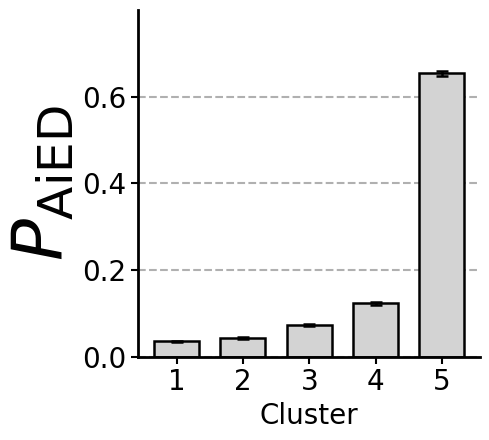

In [17]:
# ======================================================
# Figure 6C: Cluster Mean AiED Probability ± SEM
# Based on Figure6_C_corrected.ipynb
# ======================================================

import numpy as np
import matplotlib.pyplot as plt

# Use existing results from Figure6_C_corrected
cluster_labels = np.asarray(kmeans_label.labels_)
probabilities = np.asarray(selected_probs)

assert len(probabilities) == EXPECTED_SELECTED_N
assert len(cluster_labels) == len(probabilities)

# Original Figure 6C cluster display order
cluster_display_order = [3, 2, 0, 1, 4]
cluster_data = [
    probabilities[cluster_labels == cluster_id]
    for cluster_id in cluster_display_order
]

# Mean probability
cluster_means = [
    np.nanmean(data)
    for data in cluster_data
]

# SEM
cluster_sems = [
    np.nanstd(data, ddof=1) /
    np.sqrt(np.sum(~np.isnan(data)))
    for data in cluster_data
]

# Print statistics
for bar_idx, (cluster_id, data, mean, sem) in enumerate(
    zip(
        cluster_display_order,
        cluster_data,
        cluster_means,
        cluster_sems
    ),
    start=1
):
    print(
        f"Cluster {bar_idx} (KMeans label {cluster_id}): "
        f"N={len(data)}, "
        f"Mean={mean:.4f}, "
        f"SEM={sem:.4f}"
    )

# ======================================================
# Plot
# ======================================================

labels = ["1", "2", "3", "4", "5"]
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(5, 4.5))

ax.bar(
    x,
    cluster_means,
    width=0.68,
    color="lightgray",
    edgecolor="black",
    linewidth=1.8,
    yerr=cluster_sems,
    capsize=4,
    error_kw={
        "ecolor": "black",
        "elinewidth": 1.8,
        "capthick": 1.8
    }
)

ax.set_xlabel("Cluster", fontsize=20)

ax.set_ylabel(
    r"$P_{\mathrm{AiED}}$",
    fontsize=50
)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=20)

ax.tick_params(axis="y", labelsize=20)

ax.set_ylim(0, 0.8)
ax.set_yticks(np.arange(0, 0.8, 0.2))

ax.set_axisbelow(True)

ax.grid(
    True,
    axis="y",
    linestyle="--",
    linewidth=1.5,
    alpha=1
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

ax.tick_params(
    axis="both",
    width=1.5,
    length=5
)

plt.tight_layout()

fig.savefig(
    "Figure6_C_corrected_bar.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    "Figure6_C_corrected_bar.pdf",
    bbox_inches="tight"
)

plt.show()

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def plot_probability_scatter(
    embedding,
    probabilities,
    colorbar_label,
    output_stem,
    point_size=4,
    cmap="plasma",
    vmin=None,
    vmax=None
):
    embedding = np.asarray(embedding)
    probabilities = np.asarray(probabilities)

    assert embedding.shape[0] == len(probabilities), \
        f"embedding rows ({embedding.shape[0]}) != probabilities ({len(probabilities)})"

    fig, ax = plt.subplots(figsize=(8, 8))

    sc = ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=probabilities,
        cmap=cmap,
        s=point_size,
        linewidths=0,
        # alpha=0.9,
        vmin=vmin,
        vmax=vmax
    )

    ax.grid(True)
    ax.axis("equal")

    cbar = fig.colorbar(
        sc,
        ax=ax,
        orientation="vertical",
        fraction=0.046,
        pad=0.04
    )
    cbar.set_label(colorbar_label, fontsize=16)
    cbar.ax.tick_params(labelsize=12)

    plt.tight_layout()

    fig.savefig(output_stem + ".png", dpi=300, bbox_inches="tight")
    fig.savefig(output_stem + ".pdf", bbox_inches="tight")

    plt.show()

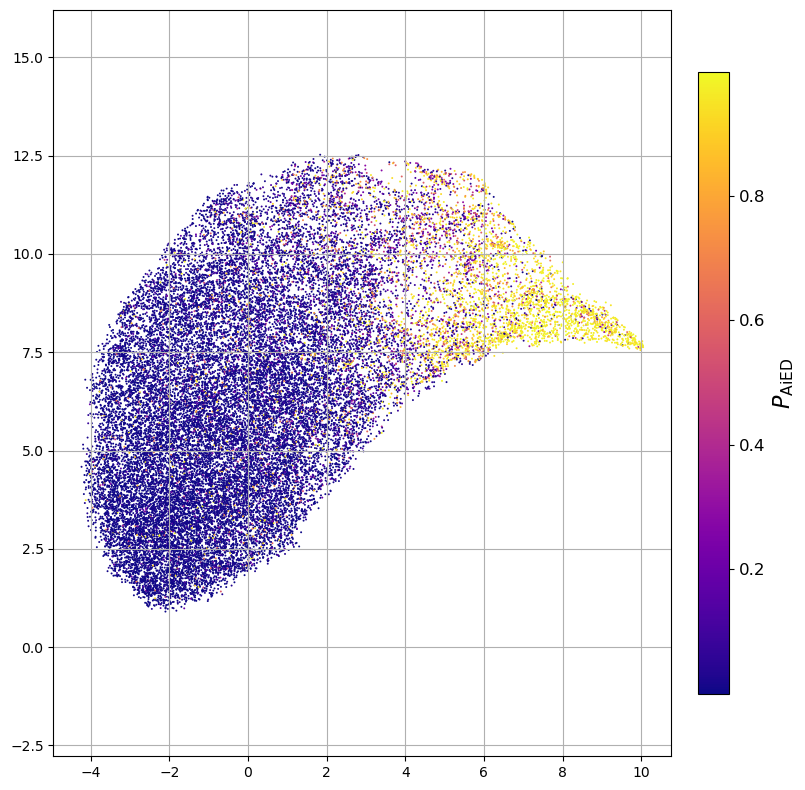

In [19]:
plot_probability_scatter(
    embedding=each_pt_embedding,
    probabilities=selected_probs,
    colorbar_label=r"$P_{\mathrm{AiED}}$",
    output_stem="Figure6_C_corrected_scatter",
    point_size=2
)